**Learning Rate Scheduling**

Learning Rate Scheduling is a technique used to change the learning rate during training. The goal is to improve the learning process by gradually reducing the learning rate as training progresses, helping to reach the optimal solution faster and more accurately.


🔹 Optimizer Used (SGD with Power Scheduling)
The optimizer used in this code is Stochastic Gradient Descent (SGD) with Power Scheduling, which adjusts the learning rate according to the following equation:

lr=lr0/(1+(steps/𝑠))^𝑐

Where:

lr0 is the initial learning rate (0.01 in this case)

steps is the number of training steps (iterations)

s is a parameter that controls how quickly the learning rate decreases

c controls the decay rate














---


**General Goal of the following Code**

This code trains a Fashion MNIST classifier using SGD with Learning Rate Scheduling (Power Scheduling). By gradually decreasing the learning rate, the model converges more efficiently while preventing instability.










In [7]:
# Loading and Preparing the Fashion MNIST Dataset:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [12]:
import tensorflow as tf
from tensorflow import keras
# Optimizer Used (SGD with Power Scheduling)
optimizer = keras.optimizers.SGD(learning_rate=0.01, decay=1e-4)
# learning_rate=0.01 → The initial learning rate.
# decay=1e-4 → The parameter that defines how quickly the learning rate will decrease during training.

In this code, decay=1e-4, meaning the learning rate decreases gradually as training progresses. This prevents the optimizer from making large, unstable updates while allowing finer adjustments as the model gets closer to the optimal solution.



In [13]:
# Building the Neural Network Model:
model = tf.keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
#Compiling the Model:
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [14]:
# Training the Model
n_epochs = 25
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7921 - loss: 0.6001 - val_accuracy: 0.8624 - val_loss: 0.4047
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8624 - loss: 0.3903 - val_accuracy: 0.8690 - val_loss: 0.3746
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8774 - loss: 0.3459 - val_accuracy: 0.8730 - val_loss: 0.3589
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8840 - loss: 0.3201 - val_accuracy: 0.8760 - val_loss: 0.3513
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8906 - loss: 0.3044 - val_accuracy: 0.8718 - val_loss: 0.3507
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8939 - loss: 0.2881 - val_accuracy: 0.8798 - val_loss: 0.3450
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8997 - loss: 0.2745 - val_accuracy: 0.8792 - val_loss: 0.3413
Epoch 8/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9067 - loss: 0.2602

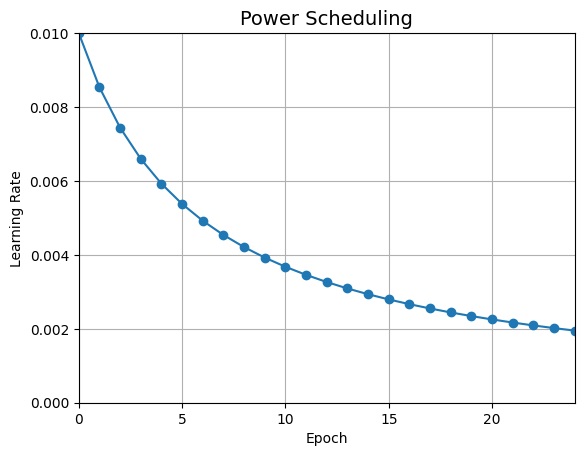

In [16]:
import math
import matplotlib.pyplot as plt
import numpy as np

learning_rate = 0.01
decay = 1e-4
batch_size = 32
n_steps_per_epoch = math.ceil(len(X_train) / batch_size)
epochs = np.arange(n_epochs)
lrs = learning_rate / (1 + decay * epochs * n_steps_per_epoch)

plt.plot(epochs, lrs,  "o-")
plt.axis([0, n_epochs - 1, 0, 0.01])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.grid(True)
plt.show()


 The figure shows a gradual decrease in the learning rate as epochs increase.
📉 Initially, the learning rate is high (0.01), which helps update the weights quickly.

 Over time, the learning rate gradually decreases, helping the model stabilize near the optimal solution without significant fluctuations.

 The goal of this gradual decrease is to prevent the model from overshooting, which improves training accuracy and reduces oscillation issues.

---


🔹 Conclusion

 This code demonstrates how the learning rate is gradually reduced using Power Scheduling.

 This approach helps improve model stability and avoid large random updates during training.

 The graph shows that the learning rate starts high and gradually decreases, allowing the weights to update quickly at first and then gradually stabilize.



---
**Performance Scheduling**

Performance scheduling adjusts the learning rate based on model performance metrics, such as validation loss. If no improvement is observed for a predefined number of steps, the learning rate is reduced.

It works by monitoring validation loss to determine when to lower the rate.

Used when the model struggles to improve, helping it escape plateaus in optimization.

**Types of Schedulers:**

Performance Scheduling

1Cycle Scheduling



The following code aims to automatically adjust the learning rate when performance plateaus using the Reduce Learning Rate on Plateau technique, where the learning rate is gradually reduced when the model's accuracy stops improving (or when the error on the validation set is not improving).

In [17]:
tf.random.set_seed(42)
np.random.seed(42)

In [18]:
# Reduce Learning Rate on Plateau
# Create a callback to control the learning rate
# Keras's ReduceLROnPlateau is used to adjust the learning rate according to the model's performance during training
# factor=0.5 → When improvement stops, the learning rate is reduced by half (50%).
# patience=5 → The model will wait 5 epochs before reducing the learning rate if performance does not improve
lr_scheduler = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

# Building the neural model
# A neural network of three hidden layers is created using "selu" activations (which works well with lecun_normal)
# The last layer contains 10 nodes with "softmax" to classify images into 10 categories (Fashion MNIST)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
# Model setup and optimization using SGD with momentum
# learning_rate=0.02 → Initial learning rate
# momentum=0.9 → Helps speed up training and overcome stuck points
optimizer = keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

# Model training with ReduceLROnPlateau
n_epochs = 25
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[lr_scheduler])
# When the error improvement on the validation set (val_loss) stops, the learning rate is automatically reduced using ReduceLROnPlateau
# callbacks=[lr_scheduler] => This line passes a ReduceLROnPlateau object (stored in lr_scheduler) as a callback when training the model using model.fit()
# When lr_scheduler is passed as a callback, it monitors the validation loss (val_loss) during training,
# and when it stops improving, it reduces the learning rate according to the specified criteria (factor=0.5, patience=5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7744 - loss: 0.7288 - val_accuracy: 0.8476 - val_loss: 0.5077 - learning_rate: 0.0200
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8350 - loss: 0.5134 - val_accuracy: 0.8492 - val_loss: 0.5359 - learning_rate: 0.0200
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8427 - loss: 0.5169 - val_accuracy: 0.8538 - val_loss: 0.5277 - learning_rate: 0.0200
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8482 - loss: 0.5095 - val_accuracy: 0.8452 - val_loss: 0.6534 - learning_rate: 0.0200
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8473 - loss: 0.5476 - val_accuracy: 0.8490 - val_loss: 0.5933 - learning_rate: 0.0200
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8501 - loss: 0.5621 - val_accuracy: 0.8564 - val_loss: 0.6358 - learning_rate: 0.0200
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8808 -



---



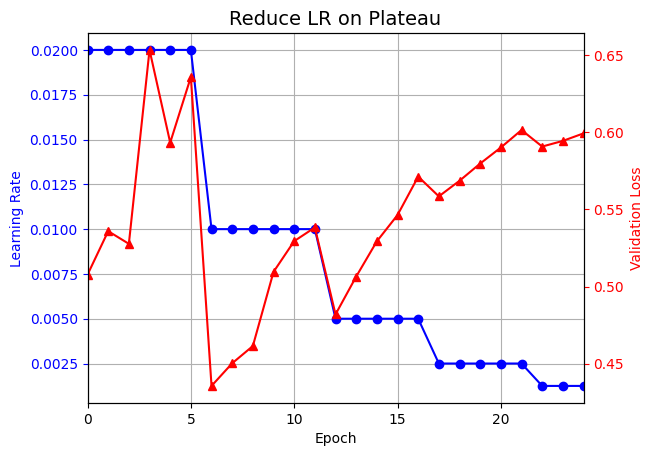

In [19]:
plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('Validation Loss', color='r')
ax2.tick_params('y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

🔵 The blue axis → represents the learning rate

🔴 The red axis → represents the validation loss

**In the Beginning (Epochs 0-5):**

val_loss (red line) fluctuates but generally decreases, indicating that the model is improving
learning_rate (blue line) remains constant at 0.02 because ReduceLROnPlateau has not been triggered yet

**In the Middle (Epochs 5-15):**

val_loss stops improving at a certain point, leading to the activation of ReduceLROnPlateau
learning_rate suddenly drops by half (0.01, then 0.005) to help the model improve with greater precision
val_loss appears to decrease slightly after the learning_rate reduction, indicating that the strategy is working well

**In the End (Epochs 15-25):**

val_loss starts to increase, signaling the beginning of overfitting, where the model becomes too adapted to the training data, making it less effective on new data
learning_rate has decreased further, but it did not prevent val_loss from rising, suggesting that the model might need to stop training at its optimal point...🤔



---



**tf.keras schedulers**
The following code trains a neural network model using the ExponentialDecay learning rate scheduler from tf.keras.optimizers.schedules

In [20]:
# Building the model (Sequential Model)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
s = 20 * len(X_train) // 32 # number of steps in 20 epochs (batch size = 32)
learning_rate = keras.optimizers.schedules.ExponentialDecay(0.01, s, 0.1)
#Initial learning rate = 0.01
# Exponentially decreasing every s step
# Decay rate = 0.1 (every s step, learning_rate is multiplied by 0.1)

# Setting up SGD as an optimizer
optimizer = keras.optimizers.SGD(learning_rate)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
n_epochs = 25
# Model training
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))


Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7949 - loss: 0.5917 - val_accuracy: 0.8610 - val_loss: 0.4001
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8631 - loss: 0.3875 - val_accuracy: 0.8706 - val_loss: 0.3716
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8752 - loss: 0.3514 - val_accuracy: 0.8752 - val_loss: 0.3577
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8839 - loss: 0.3283 - val_accuracy: 0.8760 - val_loss: 0.3486
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8891 - loss: 0.3114 - val_accuracy: 0.8742 - val_loss: 0.3425
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8935 - loss: 0.2980 - val_accuracy: 0.8770 - val_loss: 0.3381
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8987 - loss: 0.2869 - val_accuracy: 0.8790 - val_loss: 0.3347
Epoch 8/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9022 - loss: 0.2776

The learning rate (learning_rate) will start at 0.01 and then decrease exponentially as training progresses

✅ This reduces the variability of the model and helps it stabilize at optimal values

✅ If val_loss is stable or decreasing, the model is performing well

❌ If val_loss starts to rise, there may be overfitting, and EarlyStopping can be used here



---


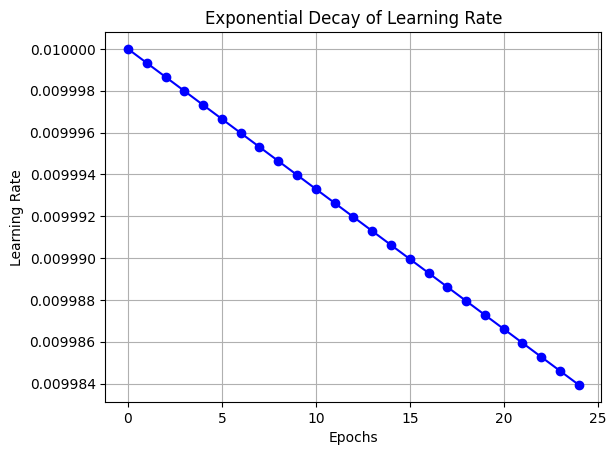

In [21]:
lrs = [learning_rate(i) for i in range(n_epochs)]
plt.plot(range(n_epochs), lrs, "bo-")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.title("Exponential Decay of Learning Rate")
plt.grid(True)
plt.show()


Initially, the learning rate is 0.01

As the epochs progress, the learning rate begins to gradually decrease exponentially

The decrease is continuous but smooth, helping the model transition from large updates at the beginning to small updates later



---
✅ Is the graph normal and correct?

✔️ Yes, the graph correctly reflects the behavior of ExponentialDecay.

✔️ The learning rate decreases slowly, which helps the model improve its performance without jumping too far from optimal values.

✔️ In the final epochs, the learning rate becomes very small, preventing the model from oscillating and allowing it to steadily approach the optimal solution.


---



**1Cycle scheduling**

1Cycle scheduling adjusts the learning rate in a cyclic manner during training, starting with a low value, increasing to a peak, and then gradually decreasing to a low value again.

Split into two phases:

Gradually increase the learning rate to a maximum value.

Gradually reduce it back to a very low value.



---


=> Ensures faster convergence and better generalization.


In [22]:
K = keras.backend
# Exponential Learning Rate
# This section contains code that helps to find the optimal learning rate using an exponential learning rate increase strategy
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs):
        self.rates.append(K.get_value(self.model.optimizer.learning_rate))
        self.losses.append(logs["loss"])
        K.set_value(self.model.optimizer.learning_rate, self.model.optimizer.learning_rate * self.factor)

def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=10**-5, max_rate=10):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = np.exp(np.log(max_rate / min_rate) / iterations)
    init_lr = K.get_value(model.optimizer.learning_rate)
    K.set_value(model.optimizer.learning_rate, min_rate)
    exp_lr = ExponentialLearningRate(factor)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    K.set_value(model.optimizer.learning_rate, init_lr)
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses)
    plt.gca().set_xscale('log')
    plt.hlines(min(losses), min(rates), max(rates))
    plt.axis([min(rates), max(rates), min(losses), (losses[0] + min(losses)) / 2])
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")

In [23]:
# OneCycleScheduler
# This section defines a One-Cycle Policy method for dynamically adjusting the learning rate during training.
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

In [27]:
# Objective: Set the learning rate at the start of each batch.
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

💡 **Strategy Summary**

**Stage | Learning Rate**

the beginning | starts from start_lr     

Increase | gradually rises to max_lr

First Decrease | gradually decreases until start_lr

Second Decrease | It goes down even more last_lr


---

**Summary**

OneCycleScheduler is an algorithm for dynamically adjusting the learning rate during training.

It works by gradually increasing the learning rate and then decreasing it in a way that helps improve the model

Linear interpolation is used to update the learning rate based on the current stage of training

The learning_rate is updated at the start of each batch according to this plan.

🛠 Using this method helps in faster training and better performance of neural models

In [26]:
# Model Building and Training
# This section defines the structure of the neural network and its training using a One-Cycle Learning Rate.
def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs,
                             max_lr=0.1)
history = model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid, y_valid),
                    callbacks=[onecycle])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6775 - loss: 0.9415 - val_accuracy: 0.8128 - val_loss: 0.5396
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8287 - loss: 0.4754 - val_accuracy: 0.8408 - val_loss: 0.4491
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8481 - loss: 0.4144 - val_accuracy: 0.8412 - val_loss: 0.4317
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8584 - loss: 0.3843 - val_accuracy: 0.8412 - val_loss: 0.4327
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8666 - loss: 0.3621 - val_accuracy: 0.8506 - val_loss: 0.4098
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8721 - loss: 0.3445 - val_accuracy: 0.8508 - val_loss: 0.4038
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8775 - loss: 0.3294 - val_accuracy: 0.8174 - val_loss: 0.4608
Epoch 8/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8822 - loss: 0.3192